 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison
Name           : Rysinska Yuliia                <br>
Student Number : L 00196821         <br>
Due Date       :  09.05.2016          <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



In [2]:
img = cv2.imread("bolognese.jpg")


# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports



In [3]:
# Path to installed Tesseract OCR engine
# Change this if installed in a different directory
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

## Install packages

In [4]:
import sys
!{sys.executable} -m pip install pytesseract opencv-python nltk spacy scikit-learn matplotlib numpy

## Imports

In [5]:
# OCR engine
import pytesseract

# Image processing
import cv2

# Numerical operations
import numpy as np

# Text cleaning
import re

# Visualization
import matplotlib.pyplot as plt

# NLP toolkit
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# Advanced NLP (Named Entity Recognition)
import spacy

# Machine learning feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Support Functions

In [6]:
# Download required datasets for NLTK processing
nltk.download('punkt')          # tokenization
nltk.download('punkt_tab')
nltk.download('stopwords')      # stop word list
nltk.download('wordnet')        # lemmatization
nltk.download('vader_lexicon')  # sentiment analysis

# Load spaCy English model for NER (Named Entity Recognition)
nlp = spacy.load("en_core_web_sm")

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Админ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Админ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Админ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Админ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Админ\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# NLP

Read image

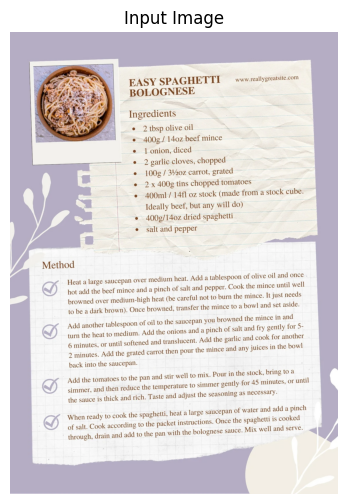

In [7]:
# Read image from file
img = cv2.imread("bolognese.jpg")
# Convert BGR (OpenCV format) → RGB (matplotlib format)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis("off")
plt.show()


OCR extraction

In [8]:
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Improve OCR accuracy
gray = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)[1]

# Extract text
raw_text = pytesseract.image_to_string(gray)

print(raw_text)

EASY SPAGHETTI www.reallygreatsite.com
13

Ingredients
© 2 tbsp olive oil
© 400g / 140z beef mince
¢ 1 onion, diced
¢ 2 garlic cloves, chopped
© 100g / 34202 carrot, grated
« 2x 400g tins chopped tomatoes
e 400ml / 14fl oz stock (made from a stock cube.
Ideally beef, but any will do)
- e 400g/140z dried spaghetti
salt and pepper

Method

Heat a large saucepan over medium heat. Add a tablespoon of olive oil and once
hot add the beef mince and a pinch of salt and pepper. Cook the mince until well
browned over medium-high heat (be careful not to burn the mince. It just needs

to be a dark brown). Once browned, transfer the mince to a bowl] and set aside.
Add another tablespoon of oil to the saucepan you browned the mince in and
turn the heat to medium. Add the onions and a pinch of salt and fry gently for 5-
6 minutes, or until softencd and translucent. Add the garlic and cook for another
2 minutes. Add the grated carrot then pour the mince and any juices in the bowl
back into the saucepa

Preprocessing

In [9]:
# Create a lemmatizer object
# Lemmatization converts words to their base form
# Example: "running" → "run"
lemmatizer = WordNetLemmatizer()

# Load English stop words
# Stop words are common words like:
# "the", "is", "and", etc.
# They usually do not add important meaning
stop_words = set(stopwords.words("english"))

# Convert OCR text to lowercase
text = raw_text.lower()

# Remove special characters and numbers
# Keep only letters and spaces
text = re.sub(r"[^a-zA-Z\s]", "", text)

# Split text into individual words (tokens)
tokens = word_tokenize(text)

# Clean and preprocess tokens
cleaned_text = " ".join([

    # Convert word to base form
    lemmatizer.lemmatize(word)

    # Loop through all tokens
    for word in tokens

    # Remove stop words
    if word not in stop_words

    # Remove very short words
    and len(word) > 2
])

# Display cleaned text
print(cleaned_text)

easy spaghetti wwwreallygreatsitecom ingredient tbsp olive oil beef mince onion diced garlic clove chopped carrot grated tin chopped tomato stock made stock cube ideally beef dried spaghetti salt pepper method heat large saucepan medium heat add tablespoon olive oil hot add beef mince pinch salt pepper cook mince well browned mediumhigh heat careful burn mince need dark brown browned transfer mince bowl set aside add another tablespoon oil saucepan browned mince turn heat medium add onion pinch salt fry gently minute softencd translucent add garlic cook another minute add grated carrot pour mince juice bowl back saucepan add tomato pan stir well mix pour stock bring sirmer reduce temperature simmer gently minute sauce thick rich taste adjust seasoning necessary large saucepan water add pinch ons spaghetti cooked ognese sauce mix well serve ready cook spaghetti heat salt cook according packet instructi drain add pan


Key Phrase Extraction using TF-IDF

In [10]:
# Create TF-IDF vectorizer
# TF-IDF finds the most important words in the text
vectorizer = TfidfVectorizer(stop_words="english")

# Convert cleaned text into numerical TF-IDF matrix
X = vectorizer.fit_transform([cleaned_text])

# Combine words with their TF-IDF scores
scores = zip(
    vectorizer.get_feature_names_out(),
    X.toarray()[0]
)

# Sort words by importance score (highest first)
key_phrases = sorted(
    scores,
    key=lambda x: x[1],
    reverse=True
)[:10]

# Display top 10 important words
print(key_phrases)

[('add', np.float64(0.45690577431012863)), ('mince', np.float64(0.3553711577967667)), ('heat', np.float64(0.25383654128340477)), ('cook', np.float64(0.20306923302672383)), ('salt', np.float64(0.20306923302672383)), ('saucepan', np.float64(0.20306923302672383)), ('spaghetti', np.float64(0.20306923302672383)), ('beef', np.float64(0.15230192477004287)), ('browned', np.float64(0.15230192477004287)), ('minute', np.float64(0.15230192477004287))]


Named Entity Recognition (NER)

In [11]:
# Process text using spaCy NLP model
doc = nlp(raw_text)

# Extract named entities
# Examples:
# PERSON → person names
# ORG → organizations
# GPE → countries/cities
entities = [

    # Store entity text + label
    (ent.text, ent.label_)

    # Loop through all detected entities
    for ent in doc.ents
]

# Display extracted entities
print(entities)

[('13', 'CARDINAL'), ('400', 'CARDINAL'), ('100', 'CARDINAL'), ('2x 400', 'CARDINAL'), ('Cook', 'PERSON'), ('another tablespoon', 'TIME'), ('6 minutes', 'TIME'), ('another\n2 minutes', 'TIME'), ('45 minutes', 'TIME'), ('Cook', 'PERSON')]


Sentiment Analysis using VADER

In [12]:
# Analyze emotional sentiment of the text
# VADER returns:
# positive score
# negative score
# neutral score
# compound score

sentiment_scores = sia.polarity_scores(raw_text)

# Display sentiment results
print(sentiment_scores)

{'neg': 0.0, 'neu': 0.889, 'pos': 0.111, 'compound': 0.9826}


===================================
# Vision

Load and Display Image

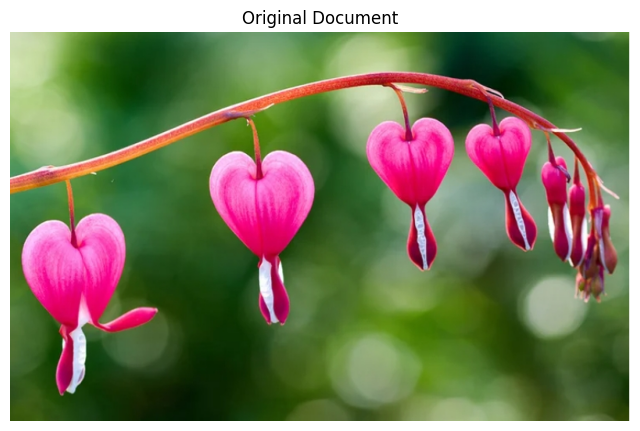

In [16]:
# Read image from file
img = cv2.imread("flower1.jpg")

# Convert BGR → RGB for matplotlib display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display original image
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Original Document")
plt.axis("off")
plt.show()

Convert to Grayscale

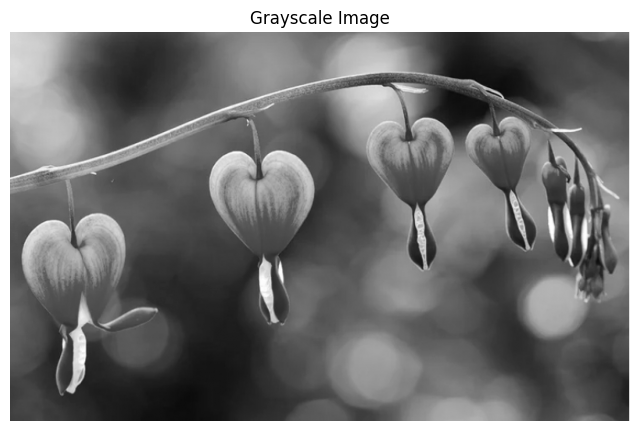

In [17]:
# Convert image to grayscale
# Simplifies processing by removing color information
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display grayscale image
plt.figure(figsize=(8,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

Noise Reduction

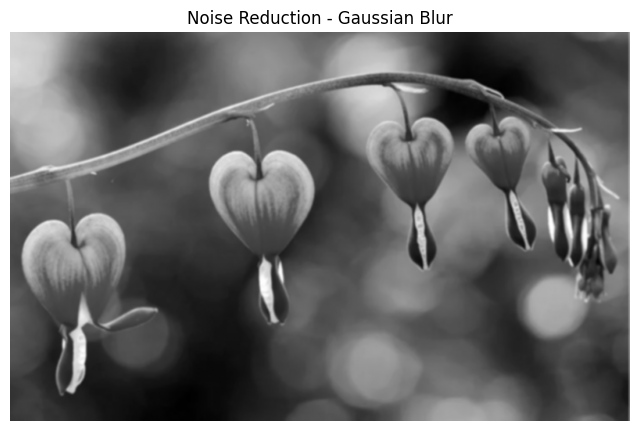

In [18]:
# Apply Gaussian Blur
# Reduces image noise and smooths image
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Display blurred image
plt.figure(figsize=(8,6))
plt.imshow(blur, cmap="gray")
plt.title("Noise Reduction - Gaussian Blur")
plt.axis("off")
plt.show()

Thresholding (Binarisation)

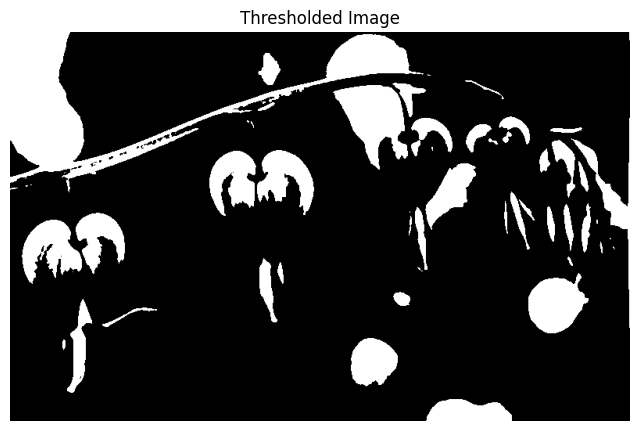

In [19]:
# Apply binary thresholding
# Converts image into black and white
_, thresh = cv2.threshold(
    blur,
    150,
    255,
    cv2.THRESH_BINARY
)

# Display thresholded image
plt.figure(figsize=(8,6))
plt.imshow(thresh, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

Contrast Enhancement

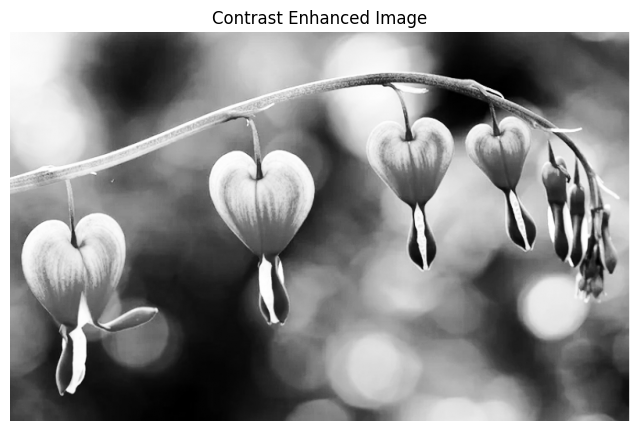

In [20]:
# Improve image contrast using histogram equalization
contrast = cv2.equalizeHist(gray)

# Display enhanced image
plt.figure(figsize=(8,6))
plt.imshow(contrast, cmap="gray")
plt.title("Contrast Enhanced Image")
plt.axis("off")
plt.show()

==============================================
# Multi-modal

## Sub Heading 1

In [14]:
# code here

# Final Output

In [15]:
# code